# Minecraft - Hypixel Cocoa Bean Market Analysis

### Minimum Requirements for API connection and Data Construction

In [15]:
import sys
import os

sys.path.append(os.path.abspath('..'))
from scripts.market_api import data_pull
from scripts.data_construction import data_construction

# Pull and Construct TS Data
data_pull()
path = "data/raw/cocoa_beans_historical.csv"
cleaned_data = data_construction(path)

print("Connection to scripts was successful... Data has been constructed")

Pinging historical data servers
Successfully Downloaded 500 time-series entries.
Starting sequential XGBoost Imputation Pipeline

--- Imputing Target Column: minBuy ---
Validation Performance -> OOS RMSE: 1.8359 | OOS R²: 14.27%
Successfully imputed 50 missing values.
Feature pool expanded. Current feature count: 13

--- Imputing Target Column: minSell ---
Validation Performance -> OOS RMSE: 0.309 | OOS R²: 28.08%
Successfully imputed 248 missing values.
Feature pool expanded. Current feature count: 14

Connection to scripts was successful... Data has been constructed


## Exploratory Analysis

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

round(cleaned_data[['buy','sell', 'buyVolume', 'sellVolume']].agg(
    ['mean',
     'std',
     'max',
     'min']
),2)

,buy,sell,buyVolume,sellVolume
mean,7.36,0.99,4696588.51,1916363.74
std,6.79,0.67,4287467.93,1346353.71
max,93.00,6.00,28405889.00,7661295.00
min,1.00,0.10,1808.00,11599.00


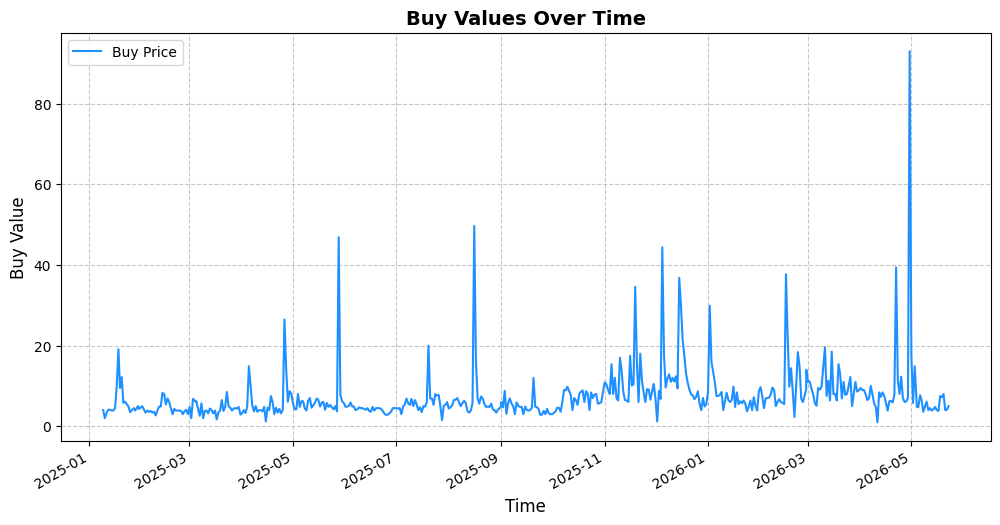

In [4]:
# Set up the figure size for better readability
plt.figure(figsize=(12, 6))

plt.plot(cleaned_data['timestamp'], cleaned_data['buy'], 
label='Buy Price', color='dodgerblue', linewidth=1.5)

plt.title('Buy Values Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Buy Value', fontsize=12)

# Add a grid for easier visual tracking of price levels
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.gcf().autofmt_xdate()

# Display the plot
plt.show()

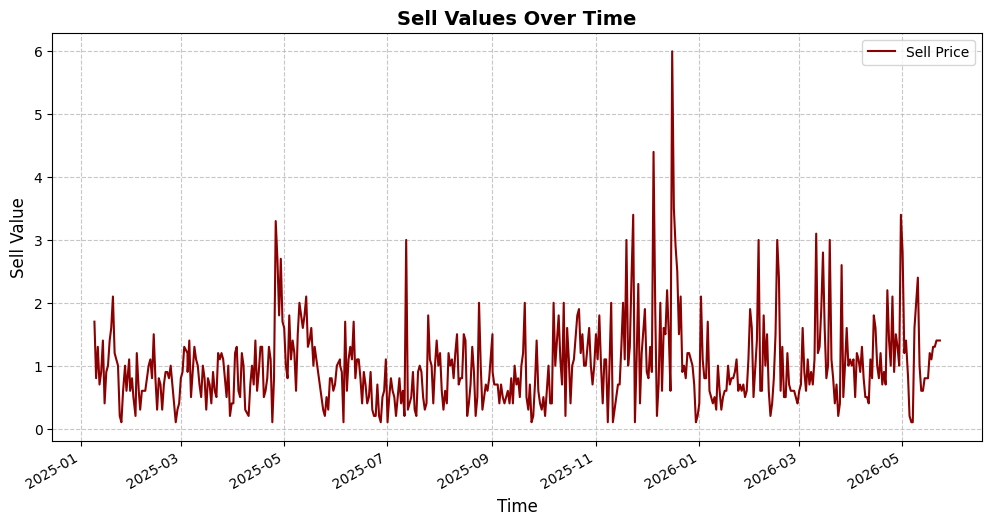

In [6]:
# Set up the figure size for better readability
plt.figure(figsize=(12, 6))

plt.plot(cleaned_data['timestamp'], cleaned_data['sell'], 
label='Sell Price', color='darkred', linewidth=1.5)

plt.title('Sell Values Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Sell Value', fontsize=12)

# Add a grid for easier visual tracking of price levels
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.gcf().autofmt_xdate()

# Display the plot
plt.show()

## First Differencing

In [16]:
differenced_data = cleaned_data[['buy', 'sell','timestamp']].copy()

differenced_data['diff_sell'] = cleaned_data['sell'] - cleaned_data['sell'].shift(1)
differenced_data['diff_buy'] = cleaned_data['buy'] - cleaned_data['buy'].shift(1)

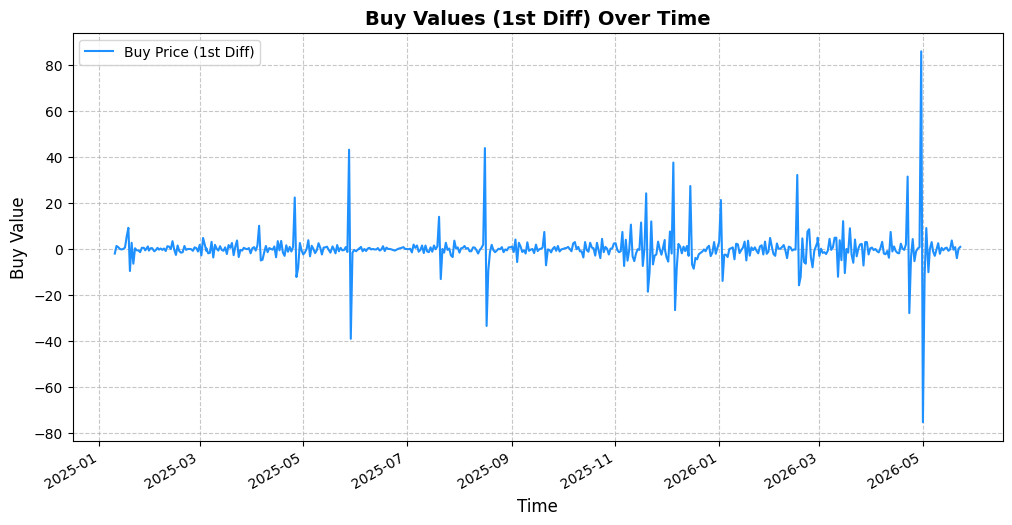

In [18]:
# Set up the figure size for better readability
plt.figure(figsize=(12, 6))

plt.plot(differenced_data['timestamp'], differenced_data['diff_buy'], 
label='Buy Price (1st Diff)', color='dodgerblue', linewidth=1.5)

plt.title('Buy Values (1st Diff) Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Buy Value', fontsize=12)

# Add a grid for easier visual tracking of price levels
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.gcf().autofmt_xdate()

# Display the plot
plt.show()

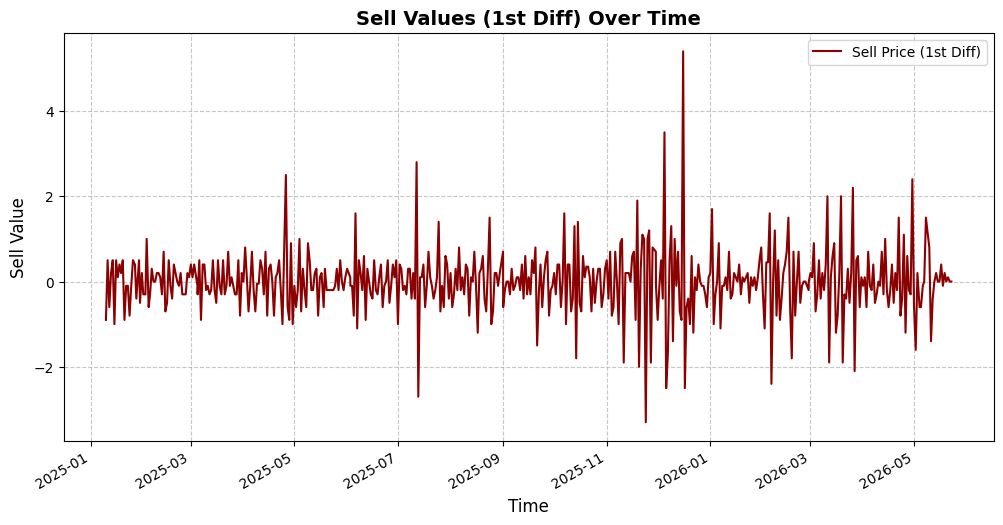

In [21]:
# Set up the figure size for better readability
plt.figure(figsize=(12, 6))

plt.plot(differenced_data['timestamp'], differenced_data['diff_sell'], 
label='Sell Price (1st Diff)', color='darkred', linewidth=1.5)

plt.title('Sell Values (1st Diff) Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Sell Value', fontsize=12)

# Add a grid for easier visual tracking of price levels
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.gcf().autofmt_xdate()

# Display the plot
plt.show()